# Part 5 — Advanced & Multivariate Models

**PyTimeSeries user guide** · *GARCH, state-space, Prophet, and VAR/VECM with Granger & cointegration.*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


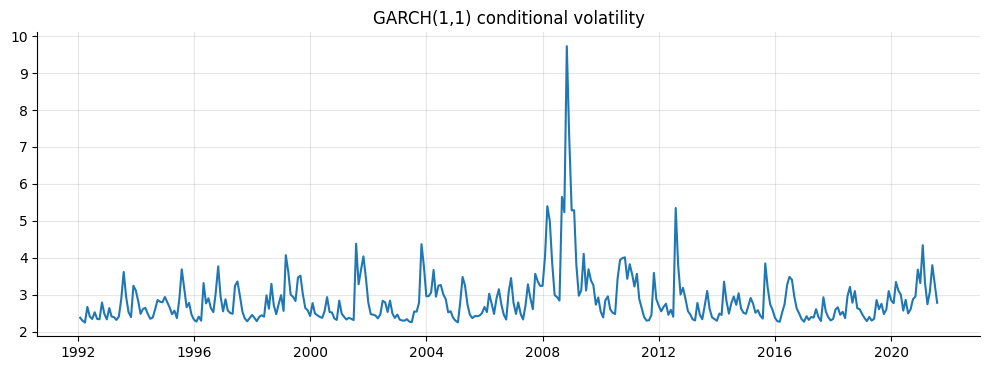

In [2]:
# GARCH volatility on monthly log-returns
ret = 100*np.log(y).diff().dropna()
g = pt.GARCH(p=1, q=1).fit(ret)
cv_ = g.conditional_volatility_
fig, ax = plt.subplots(); ax.plot(cv_.index, cv_)
ax.set_title('GARCH(1,1) conditional volatility'); plt.tight_layout(); plt.show()

In [3]:
# state-space (Kalman) and Prophet — same contract
uc = pt.UnobservedComponents(level='local linear trend', seasonal=12).fit(y)
print('UC 6-step:', uc.predict(6).round(1).tolist())
print('Prophet 6-step:', pt.Prophet(yearly_seasonality=True).fit(y).predict(6).round(1).tolist())

UC 6-step: [121.0, 120.9, 121.9, 122.7, 124.3, 125.2]


Prophet 6-step: [88.7, 87.9, 88.5, 88.8, 89.7, 89.6]


In [4]:
# multivariate: VAR / VECM on the fertilizer group
cols = ['Urea_Price','TSP_Price','MP_Price']
v = pt.VAR(maxlags=6).fit(df[cols].diff().dropna()); print('VAR lag order:', v.lag_order_)
print('Granger Urea->TSP p:', round(pt.granger_causality(df[cols].diff().dropna(),'Urea_Price','TSP_Price')['pvalue'],3))
print('Johansen coint rank:', pt.cointegration_test(df[cols])['rank'])
print('VECM 3-step:\n', pt.VECM(coint_rank=1).fit(df[cols]).predict(3).round(1))

VAR lag order: 6
Granger Urea->TSP p: 0.013
Johansen coint rank: 3
VECM 3-step:
             Urea_Price  TSP_Price  MP_Price
2021-09-01       447.2      554.4     220.4
2021-10-01       447.6      553.9     220.9
2021-11-01       447.9      553.5     221.2


**Takeaway.** Univariate advanced models (GARCH/UC/Prophet) keep the standard contract; multivariate `VAR`/`VECM` take a DataFrame and return one.